# Benchmarking OSM extraction tools

*TL;DR -- Pyrosm is the fastest OSM data parser designed for Python that can extract data to GeoDataFrames, as well as, crop large OSM.PBF files into smaller chunks by bounding box and save them to disk in PBF format (new in v0.9.0).*

`Pyrosm` aims to be an easy-to-use and fast Python tool for parsing OpenStreetMap data from Protocolbuffer Binary Format (PBF) files into [geopandas](http://geopandas.org/) which is the Python's go-to library for working with spatial data. Pyrosm has been written mainly in Cython (Python with C-like performance) using vectorized operations whenever possible which makes it very efficient for parsing OpenStreetMap data. Pyrosm deserializes the protocol buffer messages using Google’s Protobuf library with its fast C `upb` backend. Google’s Protocol Buffers is a commonly used and efficient method to serialize and compress structured data which is also used by OpenStreetMap contributors to distribute the OSM data in PBF format (Protocolbuffer Binary Format). In addition, Pyrosm uses extensively Numpy array operations and parses geometries using vectorized shapely operations which are both fast and memory efficient for data manipulation in Python.

To better understand the performance of Pyrosm, here it is compared against other similar tools. There are various tools available for parsing OSM data, such as [OSMnx](https://github.com/gboeing/osmnx), [Osmosis](https://github.com/openstreetmap/osmosis/), [pyosmium/libosmium](https://github.com/osmcode/pyosmium), [QuackOSM](https://github.com/kraina-ai/quackosm) and [osmextract (R)](https://github.com/ropensci/osmextract/). The most similar tools to Pyrosm (in terms of functionality) is OSMnx which makes it possible to retrieve OpenStreetMap data easily into GeoDataFrames utilizing OverPass API. 

Here, we compare [**pyrosm**](https://pyrosm.readthedocs.io/) against six other
widely used OpenStreetMap tools on a set of **identical, verifiable tasks**:

| Tool | What it is | Reads a local `.osm.pbf`? |
| --- | --- | --- |
| [**pyrosm**](https://pyrosm.readthedocs.io/) | Cython OSM→GeoPandas reader | yes |
| [**osmnx**](https://osmnx.readthedocs.io/) | OSM→GeoPandas/NetworkX via the Overpass API | no (downloads from Overpass) |
| [**QuackOSM**](https://github.com/kraina-ai/quackosm) | DuckDB-based OSM→GeoParquet/GeoPandas reader | yes |
| [**pyosmium**](https://osmcode.org/pyosmium/) | Python bindings to libosmium (streaming C++ reader/writer) | yes |
| [**osmium-tool**](https://osmcode.org/osmium-tool/) | C++ command-line tool (libosmium); filter + export to GeoJSON, read with GeoPandas | yes |
| [**Osmosis**](https://wiki.openstreetmap.org/wiki/Osmosis) | Java command-line tool for manipulating PBF data | yes |
| [**osmextract**](https://github.com/ropensci/osmextract) | R package: downloads and reads OSM via GDAL into `sf` | yes |

We benchmark three tasks:

1. **Parse buildings** from a region into a GeoDataFrame.
2. **Parse the road network** (`highway=*` ways) from the same region into a GeoDataFrame.
3. **Crop a large PBF** (all of Finland) down to the Helsinki region and **write the result back to disk** as a new `.osm.pbf`.

### How the comparison is kept fair

- **Same input.** For the parsing tasks every local-file tool reads the *same* PBF; OSMnx
  queries the Overpass API for the *same* geographic extent (the bounding box of that PBF).
- **Same selection.** Each tool is given the same OSM tag filter (`building` / `highway`).
- **Same output, compared by geometry type.** OSM tools disagree on whether a tag filter
  should also return tagged *nodes* (e.g. `highway=bus_stop`) or *areas*. To compare "apples with
  apples", we normalise every result to the geometry that defines the task — **polygons** for
  buildings, **lines** for roads — and report those counts side by side so you can confirm the
  tools really did the same work.
- **Timing based on multiple runs.** Each task is timed with a wall-clock median over `REPEATS` runs. QuackOSM
  is called with `ignore_cache=True` so we measure parsing, not a cache hit.
- **Verified cropping.** Each cropped PBF is read back and its building count compared, so a
  "fast" crop that dropped data is caught.

> **Not every tool can do every task.** OSMnx works from the Overpass API and does not read or
> crop local PBF files, so it does not take part in the cropping task. Osmosis manipulates PBF
> data and does not build GeoDataFrames, so it does not take part in the parsing tasks. osmextract
> (an R package) reads OSM layers through GDAL into `sf`/GeoPackage rather than writing a cropped
> `.osm.pbf`, so it joins the parsing tasks but not the cropping task. Being an R tool, its parsing results
> are produced by the companion **`osmextract_benchmark.ipynb`** (run with an R kernel), which
> writes `osmextract_results.csv`; the cell below loads it. **osmium-tool** (the libosmium command-line program) parses by exporting to GeoJSON and reading it with GeoPandas, so it joins the parsing tasks, and crops with `osmium extract` for the cropping task. The code
> below simply skips any tool that is not installed or not applicable.


### Hardware

The benchmarks are conducted with MacBook Air M5 laptop with 24GB of RAM and SSD-disk running on MacOS Tahoe 26.5. 

### Data 

- **Parsing tasks** use the **Helsinki Region** extract (~63 MB) — small enough that the
  Overpass API (and therefore OSMnx) can serve the same area for a fair comparison.
- **Cropping task** uses **all of Finland** (approx. 700 MB from Geofabrik) as the large
  input that gets cropped down to the Helsinki region.


### Results

Here, we introduce the key benchmarking results so that you don't need to read the whole document (although you can! Read further to see exact results and exact calculations). The results represent median wall-clock times from a single machine and dataset (the Helsinki-region extract for parsing, all of Finland for the crop), so they are best read as orders of magnitude rather than exact rankings. A few points help interpret them fairly.

- **The counts confirm the tools did the same work (read further to see the exact results).** Building-polygon and road-line counts agree across the local-file tools to within roughly a percent (≈176,000 buildings and ≈297,000 road lines), which is the evidence that each tool parsed the same features. OSMnx is the exception: it returns a directed routing graph from live Overpass data, so its road count (≈1.06 million edges) is not comparable/fair to the raw way counts of the other tools, which is good to keep in mind. However, we found that this was the fastest way to retrieve the network data with osmnx which is the reason why we relied on this approach. 

- **Parsing into a GeoDataFrame.** osmextract (R, GDAL-backed) is the quickest reader here, at ≈3.9 s for buildings and ≈3.1 s for roads, measured in the companion R notebook. pyrosm is the fastest of the Python tools, at ≈7.3 s and ≈13.0 s, and roughly 2-5 times as quick as QuackOSM (at 17 s and 66 s, respectively), while pyosmium is the slowest of the Python readers (≈22.6 s and ≈92.2 s): building each geometry and its tags through the WKB factory costs clearly more than pyrosm's vectorised assembly. osmium-tool looks slow at parsing (≈35 s and ≈92 s), but this does not represent the full picture regarding the efficiency of osmium as a data parser, as the time is dominated by the GeoJSON export-and-read round-trip we use to reach a GeoDataFrame. The cropping numbers below show better what that engine can actually do.

![Parsing benchmarks](figures/parse_times_bench.png)

- **Cropping a country down to a region.** osmium-tool is the clear leader, at ≈15 s on a single core and ≈4 s across ten threads, because a bounding-box extract is exactly what its C++ engine is built for. pyrosm crops in ≈110 s on one worker and ≈29 s with ten, or ≈75 s in its compact mode that matches osmium-tool's smaller output (in terms of output file size). Thus, parallelization provides a significant boost to pyrosm cropping capabilities in a similar manner as osmium-tool. Osmosis sits in the middle (≈158 s), and pyosmium is the slowest and barely benefits from more threads (≈271 s to ≈264 s), because its extract loop runs in single-threaded Python.

- **Where pyrosm fits.** pyrosm is not the single fastest tool at every task: osmextract edges it on parsing, and osmium-tool dominates cropping. It is, however, the fastest OSM parser designed for Python, and across the whole set it stays consistently among the quickest. Its main strength is the combination of versatility and ease of use. One `OSM` object reads buildings, roads, POIs, etc; the same object exports networks to igraph, NetworkX, or Pandarm and crops to a new PBF. Most of these require only a single line of code (e.g. `OSM(fp).get_buildings()`) returning a fully attributed GeoDataFrame, where pyosmium needs a hand-written WKB loop and osmium-tool needs a two-step shell pipeline plus a file read. 

![Cropping benchmarks](figures/crop_times.png)

## Running the tests

### Installation

All six tools (plus the notebook's plotting/dataframe deps) can be installed into one
environment. pyrosm, osmnx, QuackOSM and pyosmium are Python packages; Osmosis is a Java tool;
osmextract is an R package.

```bash
# Python tools (conda-forge recommended for the geo-stack)
# ipywidgets is needed so QuackOSM/DuckDB can manage their progress bar inside Jupyter.
mamba install -c conda-forge pyrosm osmnx quackosm pyosmium osmium-tool geopandas matplotlib pandas ipywidgets

# Osmosis (Java command-line tool) + a Java runtime
mamba install -c conda-forge openjdk
# then download Osmosis from https://github.com/openstreetmap/osmosis/releases
# and make sure the `osmosis` launcher is on your PATH.

# osmextract is an R package (run via the companion osmextract_benchmark.ipynb).
# Install R + sf (GDAL) + the Jupyter R kernel from conda-forge, then osmextract from CRAN:
mamba install -c conda-forge r-base r-sf r-irkernel
R -e 'install.packages("osmextract", repos="https://cloud.r-project.org")'
R -e 'IRkernel::installspec()'   # registers the "R" Jupyter kernel
```

If a tool is missing, its cells below are skipped automatically (they are guarded by an
availability check), so the rest of the notebook still runs end to end.


### Setup: imports, tool detection and helpers

In [1]:
import os
import time
import shutil
import statistics
import subprocess
import tempfile
import warnings
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")  # keep the benchmark output readable

# How many times each parsing task is repeated (median is reported).
REPEATS = 3
# Cropping reads/writes a multi-hundred-MB file; once is enough.
CROP_REPEATS = 1

In [2]:
# Import the Python tools and record which ones are installed.
# (Osmosis is a separate command-line program, so we look for it on PATH.)
import pyrosm
from pyrosm import OSM, get_data
import osmnx as ox
import quackosm as qosm
import osmium
from importlib.metadata import version

import re
import subprocess


def osmosis_version(osmosis_bin="osmosis"):
    """Return the Osmosis version (e.g. '0.49.2'), or None if it can't be determined.

    Osmosis has no plain --version flag, but it logs 'Osmosis Version X.Y.Z' to stderr
    at startup, so we run a harmless command (--help) and parse that line.
    """
    try:
        result = subprocess.run(
            [osmosis_bin, "--help"], capture_output=True, text=True, timeout=30,
        )
    except (OSError, subprocess.SubprocessError):
        return None
    match = re.search(r"Osmosis Version (\S+)", result.stdout + result.stderr)
    return match.group(1) if match else None


def osmium_tool_version(osmium_bin="osmium"):
    """Return the osmium-tool version (e.g. '1.19.0'), or None if it can't be determined.

    The osmium command-line tool (separate from the pyosmium bindings) prints
    'osmium version X.Y.Z' on `osmium --version`, so we run it and parse that line.
    """
    try:
        result = subprocess.run(
            [osmium_bin, "--version"], capture_output=True, text=True, timeout=30,
        )
    except (OSError, subprocess.SubprocessError):
        return None
    match = re.search(r"osmium version (\S+)", result.stdout + result.stderr)
    return match.group(1) if match else None


# Command-line tools (found on PATH).
OSMOSIS_BIN = shutil.which("osmosis")
OSMIUM_BIN = shutil.which("osmium")

available_tools = {
    "pyrosm": pyrosm.__version__,
    "osmnx": ox.__version__,
    "quackosm": qosm.__version__,
    "pyosmium": version("osmium"),
    "osmosis": osmosis_version(OSMOSIS_BIN) if OSMOSIS_BIN else None,
    "osmium-tool": osmium_tool_version(OSMIUM_BIN) if OSMIUM_BIN else None,
}


def is_installed(tool):
    """True if `tool` was detected above (used to skip tools that aren't installed)."""
    return bool(available_tools.get(tool))


print("Detected tools:")
for tool, info in available_tools.items():
    print(f"  {tool:9} {info or 'NOT available'}")

Detected tools:
  pyrosm    0.8.0
  osmnx     2.1.0
  quackosm  0.17.1
  pyosmium  4.3.1
  osmosis   0.49.2
  osmium-tool 1.19.0


In [3]:
# Each benchmark run appends one row (a dict) to this list which is turned into a table later
parsing_results = []

# A tag filter can return several geometry types (a `highway` filter, for instance, also
# returns bus-stop *points*). To compare tools fairly we count only the geometry that
# defines the task: polygons for buildings, lines for roads
POLYGON_TYPES = {"Polygon", "MultiPolygon"}
LINE_TYPES = {"LineString", "MultiLineString"}


def count_polygons(geodataframe):
    """Number of polygon rows in the GeoDataFrame."""
    return int(geodataframe.geometry.geom_type.isin(POLYGON_TYPES).sum())


def count_lines(geodataframe):
    """Number of line rows in the GeoDataFrame."""
    return int(geodataframe.geometry.geom_type.isin(LINE_TYPES).sum())


def median_runtime(function, repeats, *args):
    """Call function(*args) `repeats` times; return median seconds and the last result of the run."""
    runtimes = []
    result = None
    for i in range(repeats):
        started = time.perf_counter()
        result = function(*args)
        runtimes.append(time.perf_counter() - started)
    return statistics.median(runtimes), result


def bounding_box_of(geodataframe):
    """Extent of a GeoDataFrame as a shapely box (used to give osmnx the same area)."""
    from shapely.geometry import box
    if geodataframe is None or geodataframe.empty:
        return None
    return box(*geodataframe.total_bounds)


def run_parsing_task(task, tool, parse, count_features, repeats=REPEATS):
    """Benchmark one tool on one parsing task and store the result.

    `parse` returns a GeoDataFrame; `count_features` is count_polygons or count_lines.
    Tools that aren't installed are skipped, and errors are recorded instead of raised.
    Returns the parsed GeoDataFrame so the caller can reuse it.
    """
    if not is_installed(tool):
        print(f"  {tool:9} not installed - skipped")
        return None

    try:
        seconds, geodataframe = median_runtime(parse, repeats)
    except Exception as error:
        parsing_results.append({
            "task": task, "tool": tool, "seconds": None,
            "features": None, "status": f"{type(error).__name__}: {error}",
        })
        print(f"  {tool:9} FAILED - {error}")
        return None

    features = count_features(geodataframe)
    parsing_results.append({
        "task": task, "tool": tool, "seconds": round(seconds, 2),
        "features": features, "status": "ok",
    })
    print(f"  {tool:9} {seconds:6.2f} s   {features:>7,} features")
    return geodataframe

In [4]:
# pyosmium streams OSM elements but has no GeoDataFrame API, so these helpers build the
# geometry (with libosmium's WKB factory) AND collect every tag, producing a full
# attribute table comparable to what pyrosm / QuackOSM / osmnx return.


def read_polygons_with_pyosmium(pbf_path, key, location_storage="flex_mem"):
    """Read every area (closed way or multipolygon) carrying `key` -> polygons + tags."""
    from shapely import from_wkb

    wkb_factory = osmium.geom.WKBFactory()
    rows = []

    fp = (osmium.FileProcessor(pbf_path)
          .with_locations(location_storage)
          .with_areas(osmium.filter.KeyFilter(key))   # pass 1: only assemble key-tagged relations
          .with_filter(osmium.filter.KeyFilter(key)))  # output: only yield key-tagged objects

    for element in fp:
        if not element.is_area():
            continue
        try:
            wkb = wkb_factory.create_multipolygon(element)
        except Exception:
            continue
        if wkb:
            row = {tag.k: tag.v for tag in element.tags}
            row["geometry"] = from_wkb(bytes.fromhex(wkb))
            rows.append(row)

    if not rows:
        return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
    return gpd.GeoDataFrame(rows, geometry="geometry", crs="EPSG:4326")


def read_lines_with_pyosmium(pbf_path, key, location_storage="flex_mem"):
    """Read every way carrying `key` -> linestrings + tags."""
    from shapely import from_wkb

    wkb_factory = osmium.geom.WKBFactory()
    rows = []

    fp = (osmium.FileProcessor(pbf_path, osmium.osm.NODE | osmium.osm.WAY)
          .with_locations(location_storage)
          .with_filter(osmium.filter.KeyFilter(key)))

    for element in fp:
        if not (element.is_way() and len(element.nodes) >= 2):
            continue
        try:
            wkb = wkb_factory.create_linestring(element)
        except Exception:
            continue
        if wkb:
            row = {tag.k: tag.v for tag in element.tags}
            row["geometry"] = from_wkb(bytes.fromhex(wkb))
            rows.append(row)

    if not rows:
        return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
    return gpd.GeoDataFrame(rows, geometry="geometry", crs="EPSG:4326")


def crop_with_pyosmium(input_pbf, output_pbf, bbox):
    """Crop `input_pbf` to a bounding box (keeping complete ways) and write `output_pbf`.

    Three passes over the file:
      1. find the ids of nodes inside the box,
      2. find ways that touch the box, keeping ALL of their nodes so border-crossing ways
         stay whole,
      3. write the kept nodes, ways and relations.
    """
    if os.path.exists(output_pbf):
        os.remove(output_pbf)
    west, south, east, north = bbox

    nodes_in_box = set()
    for node in (osmium.FileProcessor(input_pbf)
                 .with_filter(osmium.filter.EntityFilter(osmium.osm.NODE))):
        if west <= node.location.lon <= east and south <= node.location.lat <= north:
            nodes_in_box.add(node.id)

    ways_to_keep = set()
    nodes_to_keep = set(nodes_in_box)
    for way in (osmium.FileProcessor(input_pbf)
                .with_filter(osmium.filter.EntityFilter(osmium.osm.WAY))):
        way_node_ids = [node.ref for node in way.nodes]
        if any(node_id in nodes_in_box for node_id in way_node_ids):
            ways_to_keep.add(way.id)
            nodes_to_keep.update(way_node_ids)

    writer = osmium.SimpleWriter(output_pbf)
    try:
        for element in osmium.FileProcessor(input_pbf):
            if element.is_node() and element.id in nodes_to_keep:
                writer.add_node(element)
            elif element.is_way() and element.id in ways_to_keep:
                writer.add_way(element)
            elif element.is_relation() and any(
                (member.type == "w" and member.ref in ways_to_keep)
                or (member.type == "n" and member.ref in nodes_to_keep)
                for member in element.members
            ):
                writer.add_relation(element)
    finally:
        writer.close()
    return output_pbf


def crop_with_osmosis(input_pbf, output_pbf, bbox, osmosis_bin):
    """Crop to a bounding box (complete ways) by calling the Osmosis command-line tool."""
    if os.path.exists(output_pbf):
        os.remove(output_pbf)
    west, south, east, north = bbox
    subprocess.run(
        [osmosis_bin,
         "--read-pbf", str(input_pbf),
         "--bounding-box", f"left={west}", f"bottom={south}",
         f"right={east}", f"top={north}", "completeWays=yes",
         "--write-pbf", str(output_pbf)],
        check=True,
    )
    return output_pbf


# osmium-tool is the C++ command-line program (separate from the pyosmium bindings). It has
# no GeoDataFrame API either, so we filter + export to GeoJSON Text Sequence on disk and read
# that back with geopandas.

def parse_with_osmium_tool(pbf_path, key, geometry_type, osmium_bin="osmium"):
    """Parse features tagged `key` into a GeoDataFrame using the osmium command-line tool.

    Two commands plus a read:
      1. osmium tags-filter -> keep objects carrying `key` (and the nodes/members they
         reference, so geometries can be built),
      2. osmium export -> write GeoJSON Text Sequence, keeping only `geometry_type`
         ("polygon" or "linestring"); this replaces the manual geometry-type split the
         pyosmium helpers do,
      3. geopandas reads the .geojsonseq.

    Notice: This is not the way osmium is typically used as the core focus of the library is not to export
    the data to GIS file formats or GeoDataFrame. Thus, this functionality represents a workaround which is not
    optimized at all in terms of performance. 
    """
    work_dir = tempfile.gettempdir()
    filtered_pbf = os.path.join(work_dir, f"osmium_{key}.osm.pbf")
    geojson_seq = os.path.join(work_dir, f"osmium_{key}.geojsonseq")

    subprocess.run(
        [osmium_bin, "tags-filter", "--overwrite", pbf_path, f"w/{key}", "-o", filtered_pbf],
        check=True, capture_output=True,
    )
    subprocess.run(
        [osmium_bin, "export", "--overwrite", filtered_pbf,
         "--geometry-types", geometry_type, "-f", "geojsonseq", "-o", geojson_seq],
        check=True, capture_output=True,
    )
    return gpd.read_file(geojson_seq)


def crop_with_osmium_tool(input_pbf, output_pbf, bbox, pool_threads=None, osmium_bin="osmium"):
    """Crop to a bounding box (complete ways) with the osmium command-line tool.

    `pool_threads` sets OSMIUM_POOL_THREADS for the run -- libosmium's PBF (de)compression
    thread pool. None uses libosmium's default (~ CPU count); 1 forces single-threaded.
    """
    west, south, east, north = bbox
    env = dict(os.environ)
    if pool_threads is not None:
        env["OSMIUM_POOL_THREADS"] = str(pool_threads)
    subprocess.run(
        [osmium_bin, "extract", "--overwrite",
         "--strategy", "complete_ways",
         "--bbox", f"{west},{south},{east},{north}",
         input_pbf, "-o", output_pbf],
        env=env, check=True, capture_output=True,
    )
    return output_pbf

### Data 

- **Parsing tasks** use the **Helsinki Region** extract (~63 MB) — small enough that the
  Overpass API (and therefore OSMnx) can serve the same area for a fair comparison.
- **Cropping task** uses **all of Finland** (a few hundred MB from Geofabrik) as the large
  input that gets cropped down to the Helsinki region.

Both are downloaded automatically by `pyrosm.get_data(...)`. The Finland download is large and
may take a while the first time.

In [ ]:
REGION_PBF = get_data("helsinki")   # ~63 MB, used for parsing tasks
FINLAND_PBF = get_data("finland")               # large, used as the crop input

# Helsinki region bounding box (west, south, east, north) for the cropping task.
HELSINKI_BBOX = [24.50, 60.10, 25.25, 60.40]

# QuackOSM writes intermediate GeoParquet to a working directory; keep it out of the repo.
QUACKOSM_WORKDIR = os.path.join(tempfile.gettempdir(), "quackosm_cache")

print("Region PBF :", REGION_PBF, f"({os.path.getsize(REGION_PBF)/1e6:.1f} MB)")
print("Finland PBF:", FINLAND_PBF, f"({os.path.getsize(FINLAND_PBF)/1e6:.1f} MB)")

Region PBF : /var/folders/f2/pgp09jl542zffhtrt2hx8zhh0000gp/T/pyrosm/Helsinki.osm.pbf (62.8 MB)
Finland PBF: /var/folders/f2/pgp09jl542zffhtrt2hx8zhh0000gp/T/pyrosm/finland-latest.osm.pbf (724.7 MB)


### Task 1 — Parse buildings into a GeoDataFrame

Every tool selects features tagged `building` and we compare the number of **building
polygons** produced. pyrosm runs first; its data extent defines the area of interest (`AOI`)
that OSMnx then requests from Overpass, so both look at the same region.

In [6]:
# Each function parses the buildings with one tool and returns a GeoDataFrame. Every
# local-file tool reads the SAME Helsinki-region PBF. osmnx downloads the same area
# from the Overpass API

def parse_buildings_with_pyrosm():
    return OSM(REGION_PBF).get_buildings()


def parse_buildings_with_quackosm():
    return qosm.convert_pbf_to_geodataframe(
        REGION_PBF,
        tags_filter={"building": True},
        # keep every tag as a column, like the other tools
        keep_all_tags=True,
        explode_tags=True,    
        verbosity_mode="silent",
        working_directory=QUACKOSM_WORKDIR,
        # measure the parse, not a cached result
        ignore_cache=True, 
    )


def parse_buildings_with_pyosmium():
    return read_polygons_with_pyosmium(REGION_PBF, key="building")

def parse_buildings_with_osmium():
    return parse_with_osmium_tool(REGION_PBF, "building", "polygon")

def parse_buildings_with_osmnx():
    return ox.features_from_polygon(area_of_interest, tags={"building": True})


print("Task 1 - parse buildings (counts are building polygons):\n")

# pyrosm's result defines the area of interest for osmnx 
buildings = run_parsing_task("buildings", "pyrosm", parse_buildings_with_pyrosm, count_polygons)
area_of_interest = bounding_box_of(buildings)

# run_parsing_task returns each GeoDataFrame
_ = run_parsing_task("buildings", "quackosm", parse_buildings_with_quackosm, count_polygons)
_ = run_parsing_task("buildings", "pyosmium", parse_buildings_with_pyosmium, count_polygons)
_ = run_parsing_task("buildings", "osmium-tool", parse_buildings_with_osmium, count_polygons)
_ = run_parsing_task("buildings", "osmnx", parse_buildings_with_osmnx, count_polygons, repeats=1)

Task 1 - parse buildings (counts are building polygons):

  pyrosm      7.35 s   176,868 features
  quackosm   17.03 s   176,902 features
  pyosmium   22.56 s   176,902 features
  osmium-tool  35.40 s   176,409 features
  osmnx      40.92 s   177,372 features


### Task 2 — Parse the road network into a GeoDataFrame

Every tool selects features tagged `highway` and we compare the number of **road lines**.
Tagged nodes (bus stops, crossings) and pedestrian *areas* are normalised away by counting
only `LineString`/`MultiLineString` geometries, so each tool reports the same kind of object.

In [7]:
# Each function parses the road network (highway ways) with one tool 
# and returns a GeoDataFrame

def parse_roads_with_pyrosm():
    # keep_nodes / keep_relations False -> just the highway ways, matching the other tools
    return OSM(REGION_PBF).get_data_by_custom_criteria(
        {"highway": True}, filter_type="keep", keep_nodes=False, keep_relations=False)


def parse_roads_with_quackosm():
    return qosm.convert_pbf_to_geodataframe(
        REGION_PBF,
        tags_filter={"highway": True},
        keep_all_tags=True,
        explode_tags=True,
        ignore_cache=True,
        verbosity_mode="silent",
        working_directory=QUACKOSM_WORKDIR,
    )


def parse_roads_with_pyosmium():
    return read_lines_with_pyosmium(REGION_PBF, key="highway")


def parse_roads_with_osmium():
    return parse_with_osmium_tool(REGION_PBF, "highway", "linestring")


def parse_roads_with_osmnx():
    # osmnx downloads from Overpass. graph_from_polygon(network_type="all") fetches only the
    # highway ways (not every highway-tagged node). Returns a graph which is turned into a GeoDataFrame. 
    # The line count differs from the other tools as osmnx returns simplified network. 
    # 'use_cache' is off so each run really hits Overpass.
    ox.settings.use_cache = False
    graph = ox.graph_from_polygon(area_of_interest, network_type="all", retain_all=True)
    return ox.graph_to_gdfs(graph, nodes=False)


print("Task 2 - parse the road network (counts are highway lines):\n")

# run_parsing_task returns each GeoDataFrame
_ = run_parsing_task("roads", "pyrosm", parse_roads_with_pyrosm, count_lines)
_ = run_parsing_task("roads", "quackosm", parse_roads_with_quackosm, count_lines)
_ = run_parsing_task("roads", "pyosmium", parse_roads_with_pyosmium, count_lines)
_ = run_parsing_task("roads", "osmium-tool", parse_roads_with_osmium, count_lines)
_ = run_parsing_task("roads", "osmnx", parse_roads_with_osmnx, count_lines, repeats=1)

Task 2 - parse the road network (counts are highway lines):

  pyrosm     13.02 s   296,783 features
  quackosm   66.32 s   296,549 features
  pyosmium   92.19 s   300,015 features


Skipping field duration: unsupported OGR type: 10
Skipping field duration: unsupported OGR type: 10
Skipping field duration: unsupported OGR type: 10


  osmium-tool 143.10 s   296,783 features
  osmnx      90.29 s   1,059,349 features


In [10]:
# Save parsing results to disk
parsing_df = pd.DataFrame(parsing_results)
parsing_df.to_csv("osm_parsing_results.csv", index=False)

### Task 3 — Crop a large PBF to a region and save to disk

Crop the **Finland** PBF down to the **Helsinki region** bounding box and write a new
`.osm.pbf`. All four croppers keep **complete ways** (ways crossing the box keep all their
nodes), so the outputs are directly comparable. Each result is read back and its building
count reported to confirm the crop is a valid subset (the full Finland file has far more).

OSMnx and QuackOSM are not part of this task: OSMnx does not handle local PBF files, and
QuackOSM converts PBF to GeoParquet rather than writing a cropped `.osm.pbf`.

To keep this a **fair per-core comparison**, each tool is pinned to a single core here: pyrosm
runs at `workers=1` and osmium-tool at `OSMIUM_POOL_THREADS=1`; pyosmium's extract loop is
single-threaded Python anyway. Osmosis is the exception — its Java pipeline uses several threads
and can't be cleanly pinned, so read its time with that caveat. The next section lets every tool
use **all** cores to show how each one scales.

In [10]:
# Crop the large Finland PBF down to the Helsinki-region bounding box and write a new
# .osm.pbf. Each cropper keeps complete ways; we read the result back and report how many
# buildings it contains, to confirm the crop is a valid subset.

crop_results = []
crop_dir = tempfile.gettempdir()


def time_crop_and_verify(crop_function, *args):
    """Run a crop once; return (seconds, output size in MB, buildings read back)."""
    seconds, output_path = median_runtime(crop_function, CROP_REPEATS, *args)
    size_mb = round(os.path.getsize(output_path) / 1e6, 1)
    buildings = len(OSM(output_path).get_buildings())
    return seconds, size_mb, buildings


def run_crop_task(tool, crop_function):
    if not is_installed(tool):
        print(f"  {tool:9} not installed - skipped")
        return
    try:
        seconds, size_mb, buildings = time_crop_and_verify(crop_function)
    except Exception as error:
        crop_results.append({"tool": tool, "seconds": None, "out_mb": None,
                             "buildings": None, "status": f"{type(error).__name__}: {error}"})
        print(f"  {tool:9} FAILED - {error}")
        return
    crop_results.append({"tool": tool, "seconds": round(seconds, 1), "out_mb": size_mb,
                         "buildings": buildings, "status": "ok"})
    print(f"  {tool:9} {seconds:6.1f} s   {size_mb:6.1f} MB   {buildings:,} buildings")


def crop_finland_with_pyrosm():
    output_path = os.path.join(crop_dir, "crop_pyrosm.osm.pbf")
    OSM(FINLAND_PBF, bounding_box=HELSINKI_BBOX).to_pbf(output_path, repack=True)
    return output_path


def crop_finland_with_pyosmium():
    output_path = os.path.join(crop_dir, "crop_pyosmium.osm.pbf")
    return crop_with_pyosmium(FINLAND_PBF, output_path, HELSINKI_BBOX)


def crop_finland_with_osmosis():
    output_path = os.path.join(crop_dir, "crop_osmosis.osm.pbf")
    return crop_with_osmosis(FINLAND_PBF, output_path, HELSINKI_BBOX, OSMOSIS_BIN)


def crop_finland_with_osmium():
    # single core (OSMIUM_POOL_THREADS=1) so the main table is a fair per-core comparison
    output_path = os.path.join(crop_dir, "crop_osmium.osm.pbf")
    return crop_with_osmium_tool(FINLAND_PBF, output_path, HELSINKI_BBOX, pool_threads=1)


print("Task 3 - crop Finland to the Helsinki region (buildings = count read back):\n")

run_crop_task("pyrosm", crop_finland_with_pyrosm)
run_crop_task("pyosmium", crop_finland_with_pyosmium)
run_crop_task("osmium-tool", crop_finland_with_osmium)
run_crop_task("osmosis", crop_finland_with_osmosis)

Task 3 - crop Finland to the Helsinki region (buildings = count read back):

  pyrosm     110.2 s     59.5 MB   208,586 buildings
  pyosmium   270.7 s     59.5 MB   208,586 buildings
  osmium-tool   15.0 s     59.6 MB   208,586 buildings


Jun 15, 2026 7:48:25 PM org.openstreetmap.osmosis.core.Osmosis run
INFO: Osmosis Version 0.49.2
SLF4J: Failed to load class "org.slf4j.impl.StaticLoggerBinder".
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See http://www.slf4j.org/codes.html#StaticLoggerBinder for further details.
Jun 15, 2026 7:48:25 PM org.openstreetmap.osmosis.core.Osmosis run
INFO: Preparing pipeline.
Jun 15, 2026 7:48:25 PM org.openstreetmap.osmosis.core.Osmosis run
INFO: Launching pipeline execution.
Jun 15, 2026 7:48:25 PM org.openstreetmap.osmosis.core.Osmosis run
INFO: Pipeline executing, waiting for completion.
Jun 15, 2026 7:51:03 PM org.openstreetmap.osmosis.core.Osmosis run
INFO: Pipeline complete.
Jun 15, 2026 7:51:03 PM org.openstreetmap.osmosis.core.Osmosis run
INFO: Total execution time: 157458 milliseconds.


  osmosis    157.6 s     59.1 MB   208,586 buildings


### Task 3 with multiprocessing / multithreading — does parallelism speed up the crop?

Re-run the Finland → Helsinki crop in parallel, using each tool's own mechanism:

- **pyrosm** parallelises the extract across **processes** — `to_pbf(..., workers=N)`; compared here at `workers=1` vs `workers=10`.
- **pyosmium / libosmium** threads the PBF block **(de)compression** via the `OSMIUM_POOL_THREADS` pool, which is **on by default** (pool ≈ CPU count). It is compared at 1 vs 10 threads; because the kernel's osmium pool is already initialised by the parsing tasks, the thread count is set in a fresh **subprocess** (this adds a small fixed start-up). libosmium threads only the (de)compression — the per-element extract loop is single-threaded Python — so the benefits of multithreading is limited via pyosmium (considering slow Python loops).
- **osmium-tool** threads its whole **C++** extract pipeline via `OSMIUM_POOL_THREADS`; because the work is native C++ (not a Python loop), it scales the best of the three. (In the main Task 3 table above it was pinned to a single thread for the per-core comparison.)
- **Osmosis**'s `--bounding-box` pipeline has no worker/thread count, so it is left out from this comparison.

Each output is read back and its building count reported, exactly like Task 3, so every parallel crop is verified to keep the same data.

In [11]:
# Re-run the crop in parallel, using each tool's own mechanism, to see whether more
# workers / threads actually help:
#   - pyrosm parallelises the extract across PROCESSES via to_pbf(workers=N).
#   - pyosmium relies on libosmium's PBF (de)compression THREAD POOL (OSMIUM_POOL_THREADS,
#     on by default ~ CPU count). The kernel's pool is already fixed, so to control the
#     thread count we crop in a fresh subprocess with the env var set. It threads only the
#     (de)compression (the extract loop is single-threaded Python), so it barely scales
#     past ~2 threads.
#   - osmium-tool threads its whole C++ extract via OSMIUM_POOL_THREADS; native C++, not a
#     Python loop, so it scales best of the three.
#   - Osmosis has no worker knob for a bbox crop, so it is left out of this comparison.

N_WORKERS = 10
parallel_crop_results = []


def run_parallel_crop(label, tool, crop_function, *args):
    """Like run_crop_task, but records the parallelism setting (`label`) for each row."""
    if not is_installed(tool):
        print(f"  {label:22} not installed - skipped")
        return
    try:
        seconds, size_mb, buildings = time_crop_and_verify(crop_function, *args)
    except Exception as error:
        parallel_crop_results.append({"run": label, "tool": tool, "seconds": None,
                                      "out_mb": None, "buildings": None,
                                      "status": f"{type(error).__name__}: {error}"})
        print(f"  {label:22} FAILED - {error}")
        return
    parallel_crop_results.append({"run": label, "tool": tool, "seconds": round(seconds, 1),
                                  "out_mb": size_mb, "buildings": buildings, "status": "ok"})
    print(f"  {label:22} {seconds:6.1f} s   {size_mb:6.1f} MB   {buildings:,} buildings")


def crop_finland_with_pyrosm_workers_no_repacking(workers):
    output_path = os.path.join(crop_dir, f"crop_pyrosm_{workers}workers.osm.pbf")
    OSM(FINLAND_PBF, bounding_box=HELSINKI_BBOX).to_pbf(output_path, workers=workers, repack=False)
    return output_path

def crop_finland_with_pyrosm_workers(workers):
    output_path = os.path.join(crop_dir, f"crop_pyrosm_{workers}workers.osm.pbf")
    OSM(FINLAND_PBF, bounding_box=HELSINKI_BBOX).to_pbf(output_path, workers=workers, repack=True)
    return output_path


# Write crop_with_pyosmium out to a small script so we can run it in a subprocess with a
# chosen OSMIUM_POOL_THREADS value.
import sys
import inspect

pyosmium_crop_script = os.path.join(crop_dir, "_crop_with_pyosmium.py")
with open(pyosmium_crop_script, "w") as f:
    f.write("import os, sys, osmium\n\n")
    f.write(inspect.getsource(crop_with_pyosmium))
    f.write(
        "\n\nif __name__ == '__main__':\n"
        "    crop_with_pyosmium(sys.argv[1], sys.argv[2], [float(v) for v in sys.argv[3:7]])\n"
    )


def crop_finland_with_pyosmium_threads(threads):
    output_path = os.path.join(crop_dir, f"crop_pyosmium_{threads}threads.osm.pbf")
    environment = dict(os.environ, OSMIUM_POOL_THREADS=str(threads))
    command = [sys.executable, pyosmium_crop_script, FINLAND_PBF, output_path,
               *(str(coord) for coord in HELSINKI_BBOX)]
    subprocess.run(command, env=environment, check=True)
    return output_path


def crop_finland_with_osmium_threads(threads):
    output_path = os.path.join(crop_dir, f"crop_osmium_{threads}threads.osm.pbf")
    return crop_with_osmium_tool(FINLAND_PBF, output_path, HELSINKI_BBOX, pool_threads=threads)


print("Task 3 in parallel - more workers / threads:\n")

run_parallel_crop(f"pyrosm, {N_WORKERS} workers (fast-mode)", "pyrosm", crop_finland_with_pyrosm_workers_no_repacking, N_WORKERS)
run_parallel_crop(f"pyrosm, {N_WORKERS} workers (compact)", "pyrosm", crop_finland_with_pyrosm_workers, N_WORKERS)
run_parallel_crop(f"pyosmium, {N_WORKERS} workers", "pyosmium", crop_finland_with_pyosmium_threads, N_WORKERS)
run_parallel_crop(f"osmium-tool, {N_WORKERS} threads", "osmium-tool", crop_finland_with_osmium_threads, N_WORKERS)

if parallel_crop_results:
    display(pd.DataFrame(parallel_crop_results))

Task 3 in parallel - more workers / threads:

  pyrosm, 10 workers (fast-mode)   28.6 s     83.5 MB   208,586 buildings
  pyrosm, 10 workers (compact)   75.3 s     59.5 MB   208,586 buildings
  pyosmium, 10 workers    263.9 s     59.5 MB   208,586 buildings
  osmium-tool, 10 threads    3.8 s     59.6 MB   208,586 buildings


,run,tool,seconds,out_mb,buildings,status
0,"pyrosm, 10 workers (fast-mode)",pyrosm,28.6,83.5,208586,ok
1,"pyrosm, 10 workers (compact)",pyrosm,75.3,59.5,208586,ok
2,"pyosmium, 10 workers",pyosmium,263.9,59.5,208586,ok
3,"osmium-tool, 10 threads",osmium-tool,3.8,59.6,208586,ok


### Results - Tables and Visualizations

In [25]:
# osmextract is an R package; its results come from the companion notebook
# osmextract_benchmark.ipynb (R kernel), which writes osmextract_results.csv next to this
# file. Load those rows and add them so osmextract appears in the results table.
osmextract_csv = Path("osmextract_results.csv")
if osmextract_csv.exists():
    osmextract_df = pd.read_csv(osmextract_csv)
    print(f"Loaded {len(osmextract_df)} osmextract row(s) from {osmextract_csv}")
    parsing_df = pd.concat([parsing_df, osmextract_df])
else:
    print("osmextract_results.csv not found - run osmextract_benchmark.ipynb (R) to add it.")

Loaded 2 osmextract row(s) from osmextract_results.csv


In [ ]:

#import pandas as pd
#parsing_table = pd.read_csv("osm_parsing_results.csv")
#crop_table    = pd.read_csv("osmcrop_results.csv")

In [ ]:

parsing_table = parsing_df
print("Parsing tasks (seconds = median wall-clock; features = normalised count):")
display(parsing_table)

if crop_results:
    # Combine all results together
    all_crop_results = crop_results + parallel_crop_results
    crop_table = pd.DataFrame(all_crop_results)
    print("\nCropping task:")
    display(crop_table)

Parsing tasks (seconds = median wall-clock; features = normalised count):


,task,tool,seconds,features,status
0,buildings,pyrosm,7.35,176868,ok
1,buildings,quackosm,17.03,176902,ok
2,buildings,pyosmium,22.56,176902,ok
3,buildings,osmium-tool,35.40,176409,ok
4,buildings,osmnx,40.92,177372,ok
5,roads,pyrosm,13.02,296783,ok
6,roads,quackosm,66.32,296549,ok
7,roads,pyosmium,92.19,300015,ok
8,roads,osmium-tool,143.10,296783,ok
9,roads,osmnx,90.29,1059349,ok



Cropping task:


,tool,seconds,out_mb,buildings,status,run
0,pyrosm,110.2,59.5,208586,ok,"pyrosm, 1 worker (compact)"
1,pyosmium,270.7,59.5,208586,ok,"pyosmium, 1 worker"
2,osmium-tool,15.0,59.6,208586,ok,"osmium-tool, 1 worker"
3,osmosis,157.6,59.1,208586,ok,"osmosis, 1 worker"
4,pyrosm,28.6,83.5,208586,ok,"pyrosm, 10 workers (fast-mode)"
5,pyrosm,75.3,59.5,208586,ok,"pyrosm, 10 workers (compact)"
6,pyosmium,263.9,59.5,208586,ok,"pyosmium, 10 workers"
7,osmium-tool,3.8,59.6,208586,ok,"osmium-tool, 10 threads"


In [28]:
# ---- Styling for the result charts ----
plt.rcParams.update({
    "figure.facecolor": "white", "savefig.facecolor": "white",
    "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.edgecolor": "#888888", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#ECECF1", "grid.linewidth": 1.0,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "axes.labelcolor": "#333333",
    "xtick.color": "#333333", "ytick.color": "#333333",
})

# pyrosm is highlighted; every other tool shares one muted colour.
PYROSM_COLOR = "#2A849D"
OTHER_COLOR = "#BC778F"

def bar_colors(tools):
    return [PYROSM_COLOR if tool == "pyrosm" else OTHER_COLOR for tool in tools]

# Result figures are written here (relative to this notebook).
FIGURE_DIR = "figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

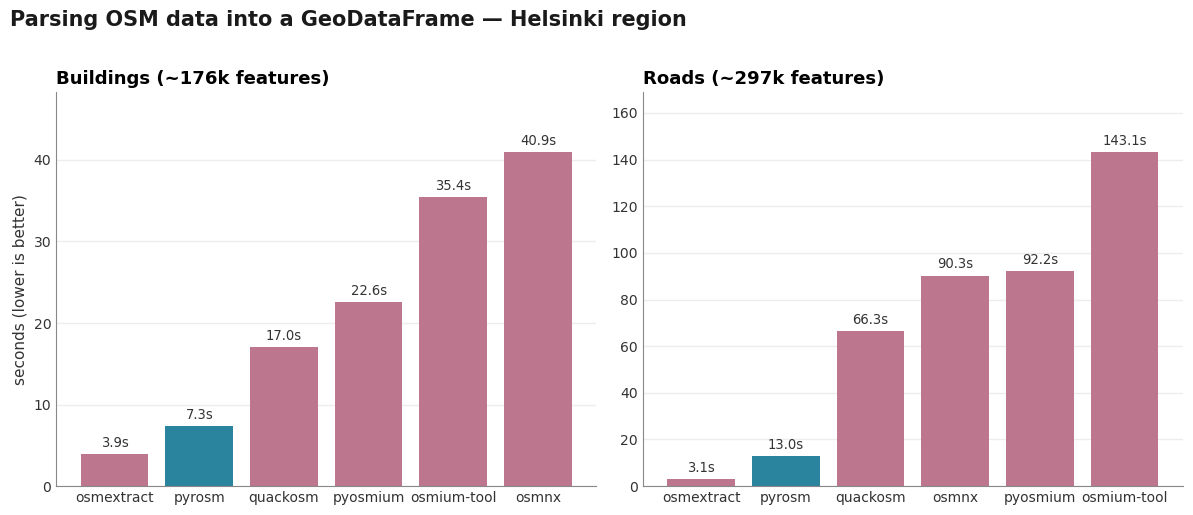

In [ ]:
# Parse times: one chart per task, with pyrosm highlighted.
parsed = parsing_table[parsing_table["status"] == "ok"]
subtitles = {"buildings": "Buildings (~176k features)", "roads": "Roads (~297k features)"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, task in zip(axes, ["buildings", "roads"]):
    rows = parsed[parsed["task"] == task].sort_values("seconds")
    bars = ax.bar(rows["tool"], rows["seconds"], color=bar_colors(rows["tool"]))
    ax.bar_label(bars, fmt="%.1fs", padding=3, fontsize=9.5, color="#333333")
    ax.set_title(subtitles[task], loc="left")
    ax.set_ylim(0, rows["seconds"].max() * 1.18)   # headroom for the bar labels
    ax.grid(axis="x", visible=False)
    ax.tick_params(length=0)

axes[0].set_ylabel("seconds (lower is better)")
fig.suptitle("Parsing OSM data into a GeoDataFrame — Helsinki region",
             fontsize=15, fontweight="bold", color="#1A1A1A", x=0.01, ha="left", y=1.02)
fig.tight_layout()
fig.savefig(f"{FIGURE_DIR}/parse_times_bench.png")
plt.show()

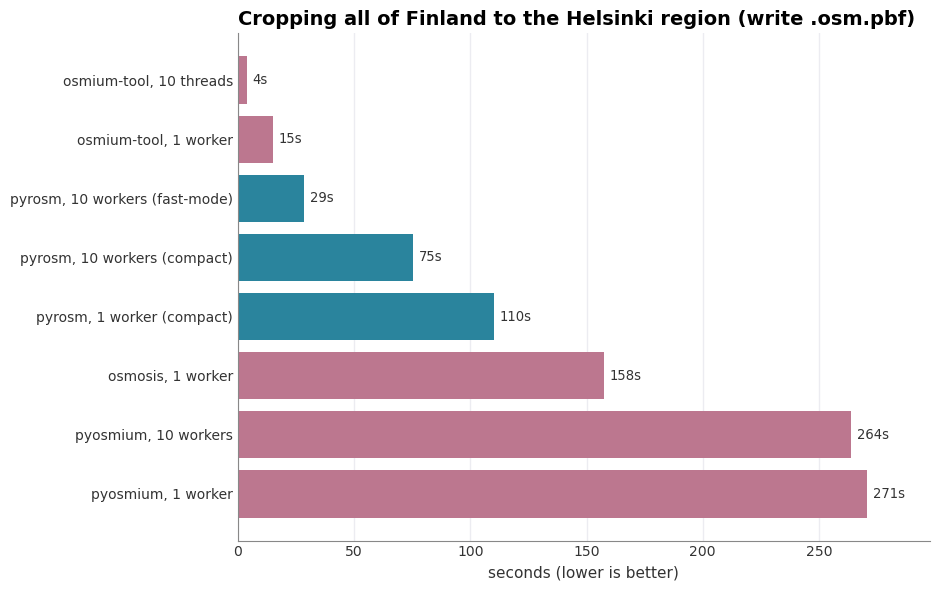

In [30]:
# Crop times: horizontal bars, fastest at the top, with pyrosm highlighted.
if "crop_table" in globals() and not crop_table.empty:
    runs = crop_table[crop_table["status"] == "ok"].sort_values("seconds")

    fig, ax = plt.subplots(figsize=(9.5, 6))
    bars = ax.barh(runs["run"], runs["seconds"], color=bar_colors(runs["tool"]))
    ax.bar_label(bars, fmt="%.0fs", padding=4, fontsize=9.5, color="#333333")
    ax.invert_yaxis()   # fastest at the top
    ax.set_xlim(0, runs["seconds"].max() * 1.10)   # headroom for the bar labels
    ax.grid(axis="y", visible=False)
    ax.tick_params(length=0)
    ax.set_xlabel("seconds (lower is better)")
    ax.set_title("Cropping all of Finland to the Helsinki region (write .osm.pbf)",
                 loc="left", fontsize=14)

    fig.tight_layout()
    fig.savefig(f"{FIGURE_DIR}/crop_times.png")
    plt.show()

## Single vs Multilayer parsing

- **One area, many layers.** The single-layer tasks above understate pyrosm's parse-once design: once an `OSM` object is initialised, every further layer (buildings, roads, POIs, …) is served from memory rather than re-read from disk. The cell below sketches that comparison against reading the file once per layer with a streaming tool:

In [36]:
# A quick illustration of pyrosm's "parse once, reuse" design: read the file once and pull
# six layers from memory, versus six separate streaming passes with pyosmium.
if is_installed("pyrosm") and is_installed("pyosmium"):
    started = time.perf_counter()
    osm = OSM(REGION_PBF)
    osm.get_buildings()
    osm.get_data_by_custom_criteria({"highway": True}, filter_type="keep",
                                    keep_nodes=False, keep_relations=False)
    osm.get_pois({"amenity": True})
    osm.get_landuse()
    osm.get_boundaries()
    osm.get_natural()
    pyrosm_seconds = time.perf_counter() - started

    started = time.perf_counter()
    read_polygons_with_pyosmium(REGION_PBF, "building")
    read_lines_with_pyosmium(REGION_PBF, "highway")
    read_polygons_with_pyosmium(REGION_PBF, "amenity")   # rough POI proxy
    read_polygons_with_pyosmium(REGION_PBF, "landuse")   # rough landuse proxy
    read_polygons_with_pyosmium(REGION_PBF, "boundary")   # rough boundary proxy
    read_polygons_with_pyosmium(REGION_PBF, "natural")   # rough natural proxy
    pyosmium_seconds = time.perf_counter() - started

    print("Buildings + roads + POIs + landuse + boundary + natural from the same area:")
    print(f"  pyrosm   (parse once, 6 layers from memory): {pyrosm_seconds:6.2f} s")
    print(f"  pyosmium (6 separate streaming passes):       {pyosmium_seconds:6.2f} s")

Buildings + roads + POIs + landuse + boundary + natural from the same area:
  pyrosm   (parse once, 6 layers from memory):  12.98 s
  pyosmium (6 separate streaming passes):        65.01 s
